   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 40.3 MB/s eta 0:00:00
Mounted at /content/drive
Cleaned Dataset Shape: (48536, 14)
Total Missing After Cleaning: 0

AdaBoost (ALL FEATURES) | Target = Category
Features = ALL (after cleaning)
Accuracy: 0.5002060156571899
                       precision    recall  f1-score   support

  Cis-acting Modifier       0.00      0.00      0.00      2406
        Primary Cause       0.00      0.00      0.00      2446
Trans-acting Modifier       0.50      1.00      0.67      4856

             accuracy                           0.50      9708
            macro avg       0.17      0.33      0.22      9708
         weighted avg       0.25      0.50      0.33      9708



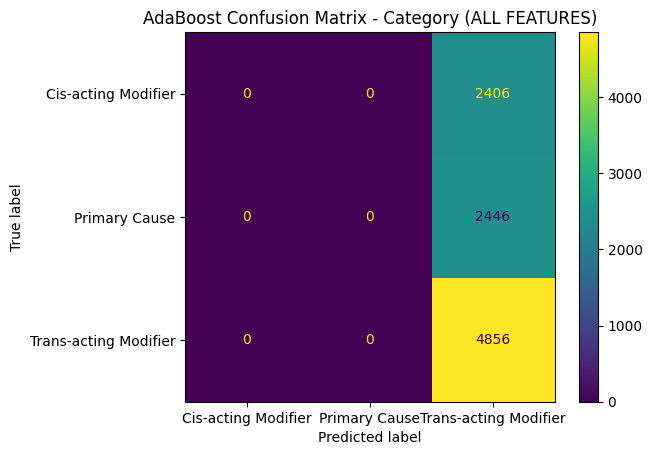


AdaBoost (ALL FEATURES) | Target = Motor_Symptoms
Features = ALL (after cleaning)
Accuracy: 0.3373506386485373
              precision    recall  f1-score   support

        Mild       0.33      0.30      0.32      3224
    Moderate       0.35      0.34      0.34      3252
      Severe       0.33      0.37      0.35      3232

    accuracy                           0.34      9708
   macro avg       0.34      0.34      0.34      9708
weighted avg       0.34      0.34      0.34      9708



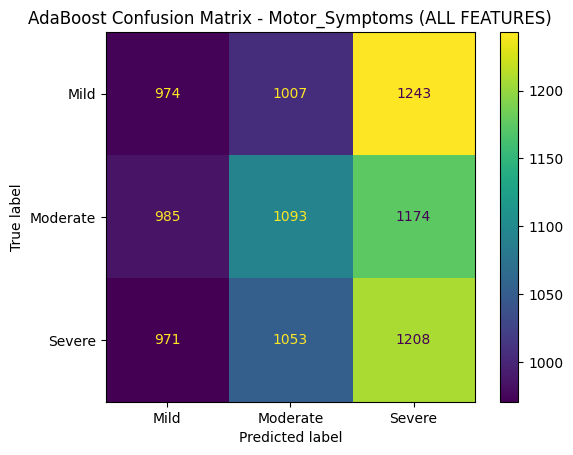


AdaBoost (ALL FEATURES) | Target = Disease_Stage
Features = ALL (after cleaning)
Accuracy: 0.2508240626287598
                 precision    recall  f1-score   support

          Early       0.25      0.18      0.21      2407
           Late       0.23      0.09      0.13      2405
         Middle       0.26      0.39      0.31      2458
Pre-Symptomatic       0.25      0.34      0.29      2438

       accuracy                           0.25      9708
      macro avg       0.25      0.25      0.23      9708
   weighted avg       0.25      0.25      0.23      9708



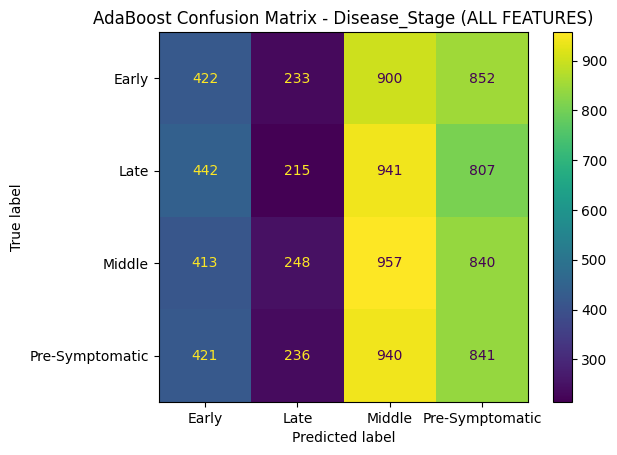


AdaBoost (NECESSARY FEATURES) | Target = Category
Features = Necessary (13)
Accuracy: 0.5002060156571899
                       precision    recall  f1-score   support

  Cis-acting Modifier       0.00      0.00      0.00      2406
        Primary Cause       0.00      0.00      0.00      2446
Trans-acting Modifier       0.50      1.00      0.67      4856

             accuracy                           0.50      9708
            macro avg       0.17      0.33      0.22      9708
         weighted avg       0.25      0.50      0.33      9708



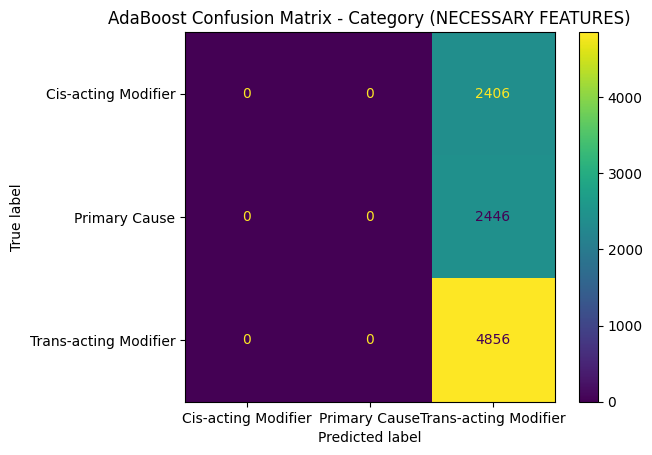

(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                     random_state=42),
                    learning_rate=0.8, n_estimators=200, random_state=42),
 LabelEncoder())

In [ ]:
# ============================================================
# INSTALL (Colab/Jupyter only)
# ============================================================
!pip -q install -U scikit-learn

import warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# ============================================================
# CONFIG
# ============================================================
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Dataset/Huntington_Disease_Dataset_Raw.csv"
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# 0) LOAD + PREPROCESS
# ============================================================

df = pd.read_csv(DATA_PATH)

# Remove noisy columns
noise_cols = [
    "Patient_ID",
    "Random_Protein_Sequence",
    "Random_Gene_Sequence",
    "Gene/Factor",
    "Function",
    "Effect",
    "Chromosome_Location"
]

df = df.drop(columns=[c for c in noise_cols if c in df.columns], errors="ignore")

# Handle missing values
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].fillna(df[c].mode()[0])

for c in df.select_dtypes(include=np.number).columns:
    df[c] = df[c].fillna(df[c].median())

# Convert object to string
for c in df.columns:
    if df[c].dtype == object:
        df[c] = df[c].astype(str)

print("Cleaned Dataset Shape:", df.shape)
print("Total Missing After Cleaning:", df.isnull().sum().sum())

# ============================================================
# 1) ADABOOST FUNCTION
# ============================================================

def run_adaboost(df_in, target, feature_cols=None, title=""):

    data = df_in.copy()

    # Select features
    if feature_cols is None:
        X = data.drop(columns=[target])
    else:
        X = data[feature_cols].copy()

    y = data[target].copy()

    # One-hot encoding
    X = pd.get_dummies(X, drop_first=False)

    # Encode target
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded,
        test_size=0.2,
        random_state=SEED,
        stratify=y_encoded
    )

    # Base learner (Decision Stump)
    base_model = DecisionTreeClassifier(
        max_depth=1,
        random_state=SEED
    )

    # AdaBoost Model
    model = AdaBoostClassifier(
        estimator=base_model,
        n_estimators=200,
        learning_rate=0.8,
        random_state=SEED
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    print("\n" + "="*70)
    print(f"AdaBoost {title} | Target = {target}")

    if feature_cols is None:
        print("Features = ALL (after cleaning)")
    else:
        print(f"Features = Necessary ({len(feature_cols)})")

    print("Accuracy:", acc)
    print(classification_report(y_test, preds, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(values_format="d")
    plt.title(f"AdaBoost Confusion Matrix - {target} {title}")
    plt.show()

    return model, le


# ============================================================
# A) ADABOOST ON ALL FEATURES (3 TARGETS)
# ============================================================

targets_all = ["Category", "Motor_Symptoms", "Disease_Stage"]

for t in targets_all:
    if t in df.columns:
        run_adaboost(
            df,
            target=t,
            feature_cols=None,
            title="(ALL FEATURES)"
        )

# ============================================================
# B) ADABOOST FOR CATEGORY USING NECESSARY FEATURES
# ============================================================

necessary_features = [
    "Age",
    "Sex",
    "Family_History",
    "HTT_CAG_Repeat_Length",
    "Gene_Mutation_Type",
    "HTT_Gene_Expression_Level",
    "Protein_Aggregation_Level",
    "Brain_Volume_Loss",
    "Functional_Capacity",
    "Cognitive_Decline",
    "Chorea_Score",
    "Motor_Symptoms",
    "Disease_Stage"
]

necessary_features = [c for c in necessary_features if c in df.columns]

run_adaboost(
    df,
    target="Category",
    feature_cols=necessary_features,
    title="(NECESSARY FEATURES)"
)